In [2]:
import pennylane as qml
import torch
import yaml
from qcm.model.reupload import HybridReuploadClassifier 
from qcm.model.reupload import QuantumHeadReupload
from qcm.data.datasets import get_dataloaders

In [3]:

def load_config(path: str) -> dict:
    with open(path, 'r') as f:
        return yaml.safe_load(f)
config = load_config('../configs/config_reupload.yaml')
dataset_type = config.get('dataset_type', 'pcam')

In [4]:
model = HybridReuploadClassifier(config=config, use_quantum=True)

In [5]:
train_loader, val_loader = get_dataloaders(config)

In [6]:
head = QuantumHeadReupload(input_shape=(3,9), num_classes=2, n_repetitions=2)

In [7]:
img, label = train_loader.dataset[0]

In [8]:
label

tensor([[0.]])

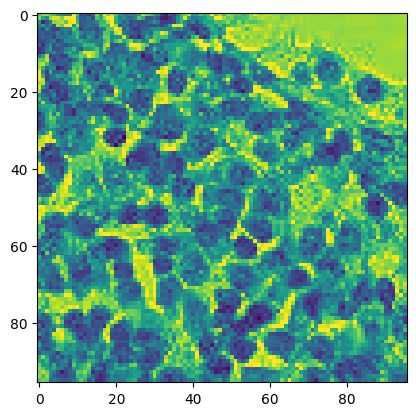

In [9]:
import matplotlib.pyplot as plt
plt.imshow(img[0])

In [10]:
latent_repr = model.backbone(img.reshape(1,3,96,96))
latent_repr.shape

torch.Size([1, 27])

In [14]:
dm = model.head.target_density_matrices
dm[label.int()]

tensor([[[[1., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.]]]])

In [15]:
model.head(latent_repr, label)

ValueError: Expected input matrix to have shape 8x8, but a matrix with shape 1x1 was passed.

In [11]:
inputs = torch.rand(27)
params = torch.rand(3, 9)
dm_y = torch.zeros((8,8))
dm_y[0,0] = 1
print(qml.draw(model.head.circuit)(inputs, params, dm_y))

0: ──Rot(0.57,0.16,0.80)──Rot(0.68,0.97,0.31)──Rot(0.90,0.89,0.68)──Rot(0.73,0.95,0.84)─╭●────╭X ···
1: ──Rot(0.05,0.47,0.97)──Rot(0.54,0.03,0.66)──Rot(0.81,0.32,0.15)──Rot(0.65,0.80,0.47)─╰X─╭●─│─ ···
2: ──Rot(0.76,0.87,0.64)──Rot(0.93,0.55,0.26)──Rot(0.45,0.39,0.60)──Rot(0.82,0.97,0.70)────╰X─╰● ···

0: ··· ──Rot(0.57,0.16,0.80)──Rot(0.68,0.97,0.31)──Rot(0.90,0.89,0.68)──Rot(0.44,0.97,0.83)─╭● ···
1: ··· ──Rot(0.05,0.47,0.97)──Rot(0.54,0.03,0.66)──Rot(0.81,0.32,0.15)──Rot(0.96,0.54,0.73)─╰X ···
2: ··· ──Rot(0.76,0.87,0.64)──Rot(0.93,0.55,0.26)──Rot(0.45,0.39,0.60)──Rot(0.41,0.31,0.28)─── ···

0: ··· ────╭X──Rot(0.57,0.16,0.80)──Rot(0.68,0.97,0.31)──Rot(0.90,0.89,0.68) ···
1: ··· ─╭●─│───Rot(0.05,0.47,0.97)──Rot(0.54,0.03,0.66)──Rot(0.81,0.32,0.15) ···
2: ··· ─╰X─╰●──Rot(0.76,0.87,0.64)──Rot(0.93,0.55,0.26)──Rot(0.45,0.39,0.60) ···

0: ··· ──Rot(0.60,0.12,0.34)─╭●────╭X─┤ ╭<𝓗(M0)>
1: ··· ──Rot(0.86,0.23,0.91)─╰X─╭●─│──┤ ├<𝓗(M0)>
2: ··· ──Rot(0.93,0.17,0.47)────╰X─╰●─┤ ╰<𝓗(M0)>

M0 = 
